# Modellierung eines Pohlschen Resonators zum Vergleich mit experimentellen Daten

Sie haben sich dafür entschieden den Versuch zu simulieren, um ihre experimentellen Daten mit dem theoretischen Modell vergleichen zu können. In diesem Notebook werden Ihnen einige Punkte zur numerischen Simulation erläutert und Sie werden schrittwiese eine solche Simulation schreiben.

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import time

## DGL 2. Ordnung $\to$ 2 DGLs 1. Ordnung

Es gibt unterschiedliche numerische Verfahren, die sich zur Lösung von Differentialgleichungen eignen. Allen diesen Verfahren ist gleich, dass sie von einem Startwert ausgehen und dann in kleinen Schritten ($\Delta t$) jeweils eine Näherung des neuen Bewegungszustands berechnen.<br>
Diese Verfahren haben gemeinsam, dass mit ihnen Differentialgleichungen erster Ordnung gelöst werden können. In einem ersten Schritt muss daher die Differentialgleichung überführt werden in 2 Differentialgleichungen 1. Ordnung. Wir nennen diese hier $\phi_1$ und $\phi_2$, wobei $\phi_1$ die WInkelauslenkung und $\phi_2$ die Winkelgeschwindigkeit beschreibt. So ergeben sich die Differentialgleichungen:
\begin{align*}
\dot{\phi}_1 &= \phi_2\\
\dot{\phi}_2 &= -\omega_0^2 \phi_1 - 2\beta \phi_1 + F_{\text{ext}}
\end{align*}

Definieren Sie zunächst eine Funktion, die dieses DGL-System abbildet:

In [ ]:
# Funktion, die das System aus 2 Differentialgleichungen erster Ordnung darstellt
# t: Zeit
# phis: numpy-Array mit den Einträgen phi_1 und phi_2
# params: Weitere Parameter, die an Funktion übergeben werden: 
# Eigenfrequenz (omega), Dämpfungskoeffizient (beta), Amplitude und Frequenz des externen Antriebs (A_ext, omega_ext)
def dgls(t,phis,params):
    omega_0 = params[0]
    beta = params[1]
    A_ext = params[2]
    omega_ext = params[3]

    phi1, phi2 = phis

    # Definieren Sie hier die jeweiligen Differentialgleichungen
    phi1dot = 
    phi2dot = 
    
    return np.array([phi1dot,phi2dot])

Im nächsten Schritt soll dieses Gleichungssystem gelöst werden.<br>
Im folgenden werden 2 unterschiedliche Verfahren vorgestellt, mithilfe derer dies möglich ist: Das Euler- und das Runge-Kutta-Verfahren.

### Euler Verfahren

Die einfachste Näherung einer Differentialgleichung erster Ordnung $\dot{x}(t) = f(t,x(t))$ stellt das Euler-Verfahren dar. Bei dieser Methode wird die Ableitung durch einen Differenzenquotienten bei einem festen Abstand $\Delta t$ approximiert. Wenn der Wert zum Zeitpunkt $t_i$ bekannt ist, dann ergibt sich der Wert für den jeweils nächsten Zeitschritt $t_{i+1}$ nach:<br>
\begin{align*}x(t_{i+1}) = x(t_i) + f(t_i,x(t_i))\,\Delta t\end{align*}
Um das System aus DGLs erster Ordnung zu lösen gilt dementsprechend:
\begin{align*}
    \phi_1(t_{i+1}) &= \phi_1(t_i) + \phi_2(t_i)\,\Delta t\\
    \phi_2(t_{i+1}) &= \phi_2(t_i) + (-\omega_0^2 \phi_1 - 2\beta \phi_1 + F_{\text{ext}}) \,\Delta t
\end{align*}

Im Folgenden ist eine Funktion "euler" definiert, die allgemein für ein System auf Differentialgleichungen diese Schritte berechnet. Ergänzen Sie diese Funktion an entsprechenden Stellen


In [ ]:
# Definition des Euler-Verfahrens für ein System aus DGLs, das über "function" definiert ist
# t0 und tfinal definieren die Start- und Endzeit
# dt definiert die Schrittweite
# phi0 definiert die Anfangsparameter
# mit params können weitere Parameter übergeben werden, die an "function" übergeben werden
def euler(function,t0,tfinal,dt,phi0,params):
    # Anzahl an Schritten ergibt sich aus dem betrachteten Zeitraum und der vorgegebenen Schrittweite dt:
    n_steps = int((tfinal-t0)/dt)

    # Definition des Zeitgrids
    t_values = np.linspace(t0,tfinal,n_steps+1)

    # Initialisierung der Werte für phi_1 und phi_2
    phi_values = np.zeros((n_steps+1,len(phi0)))

    # Setze ersten Wert auf Anfangsbedingung der DGLs
    phi_values[0] = 

    # iterative Berechnung der neuen Werte
    for i in range(n_steps):
        t_i = t_values[i]
        phi_i = phi_values[i]

        # Definiere phi_next (phi(t_{i+1})) basierend auf den Werten phi(t_i)
        # Verwende hierbei die Funktion function, 
        phi_next = 
        
        phi_values[i+1] = phi_next
    return t_values, phi_values

Überprüfen Sie hier die grundsätzliche Funktionsweise ihres Algorithmus (für arbiträre Variablen):

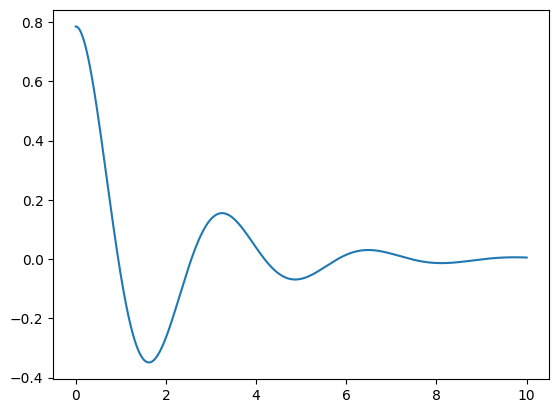

In [ ]:
# Anfangsauslenkung und -geschwindigkeit
phi0 = np.array([0.25*np.pi,0])

# Zeitschritte
dt = 0.001

# weitere Parameter: omega_0, beta, A_ext, omega_ext
params=[2,0.5,0,0]

# Anfangs- und Endzeit
t0 = 0
tfinal = 10

# Berechnung der Lösung:
# beachten Sie, dass die Funktion euler nach der momentanen Definition einen Array ausgibt - welche Einträge sind hier relevant?




plt.plot(t,phi_result)

### Runge-Kutta-Verfahren

Etwas elaborierter, als das Euler-Verfahren ist das sogenannte Runge-Kutta-Verfahren. Wir werden an dieser Stelle nicht näher auf die theoretische Herleitung dieses Verfahrens eingehen, sondern nur die Vorgehensweise beschreiben.<br>
Ebenso, wie das Euler-Verfahren, handelt es sich auch bei dem Runge-Kutta-Verfahren um ein iteratives Lösungsverfahren. Die Werte der Lösungsfunktion werden also nach und nach berechnet. Der jeweils nächste Schritt (beachten Sie, dass wir die Funktion für den Lösungsvektor $\vec{\phi}=$[$\phi_1, \phi_2$]) definieren, ergibt sich hierbei aus:
\begin{align*}
    \vec{\phi}(t_{i+1}) = \vec{\phi}(t_i) + \frac{dt}{6}\left(k_1 + 2k_2+2k_3+k_4\right),
\end{align*}
wobei die Vektor-Parameter $k_i$ definiert sind als
\begin{align*}
    k_1 &= f(t_i,\vec{\phi}(t_i))\\
    k_2 &= f(t_i + \frac{dt}{2}, \vec{\phi}(t_i) + \frac{dt}{2}k_1)\\
    k_3 &= f(t_i + \frac{dt}{2}, \vec{\phi}(t_i) + \frac{dt}{2}k_2)\\
    k_4 &= f(t_i + dt, \vec{\phi}(t_i) + dt\,k_3)
\end{align*}

Definieren Sie zunächst eine Funktion step_rk4 zur Berechnung eines solchen Schrittes:

In [ ]:
# Berechnung eines Zeitschrittes nach dem Runge-Kutta-Verfahren ind Abhängigkeit von
# der Definition des DGL-Systems: function
# dem Zeitpunkt ti und Zeitschritt dt
# den Funktionswerten zum Zeitpunkt ti: phis
# weiteren Parameter, die an die "function" übergeben werden müssen
def step_rk4(function, ti,dt, phis,params):
    # Berechnung der Parameter
    k1 = 
    k2 = 
    k3 = 
    k4 = 

    # Berechnung der Gesamtlösung:
    phis_new = phis + dt/6.0*(k1+2*k2+2*k3+k4)
    
    return phis_new

Definieren Sie im nächsten Schritt (äquivalent zum Euler-Verfahren) den iterativen Prozess zur Berechnung der Gesamtlösung:

In [ ]:
# Definition des RK4-Verfahrens für ein System aus DGLs, das über "function" definiert ist
# t0 und tfinal definieren die Start- und Endzeit
# dt definiert die Schrittweite
# phi0 definiert die Anfangsparameter
# mit params können weitere Parameter übergeben werden, die an "function" übergeben werden
def rk4(function,t0,tfinal,dt,phi0,params):
    # Anzahl an Schritten ergibt sich aus dem betrachteten Zeitraum und der vorgegebenen Schrittweite dt:
    n_steps = 
    # Definition des Zeitgrids
    t_values = 
    # Initialisierung der Werte für phi_1 und phi_2
    phi_values = 

    # Setze ersten Wert auf Anfangsbedingung der DGLs
    phi_values[0] = 
    for i in range(n_steps):
        t_i = t_values[i]
        phi_i = phi_values[i]

        # Definiere phi_next (phi(t_{i+1})) basierend auf den Werten phi(t_i)
        # Verwende hierbei die Funktion function, 
        phi_values[i+1] = 
        
    return t_values, phi_values

Überprüfe auch die grundsätzliche Funktionsweise (äquivalent zum Euler-Verfahren) dieses Algorithmus zunächst für arbiträre Variablen:

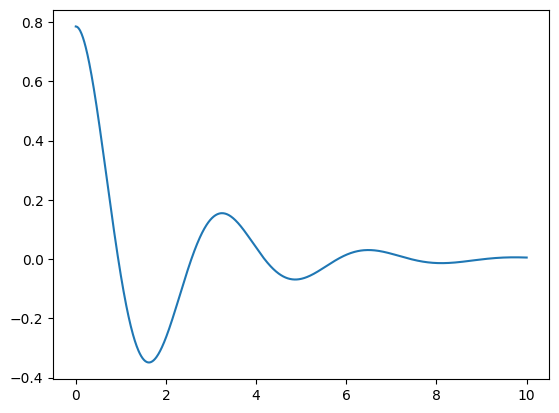

In [ ]:
# Anfangsauslenkung und -geschwindigkeit
phi0 = np.array([0.25*np.pi,0])

# Zeitschritte
dt = 0.001

# weitere Parameter: omega_0, beta, A_ext, omega_ext
params=[2,0.5,0,0]

# Anfangs- und Endzeit
t0 = 0
tfinal = 10


# Berechnen Sie nun phi_result_rk


plt.plot(t,phi_result_rk)


## Vergleich der beiden Verfahren
Vergleichen Sie im Folgenden die beiden Verfahren miteinander und mit der analytischen Lösung der Gleichung.<br>
Definieren Sie hierfür zunächst die Funktion pohl(t,phi0,params), mit den Anfangsbedingungen phi0, welche die analytische Lösung berechnet. Zur Erinnerung: Die analytische Lösung für eine getriebene, gedämpfte Schwingung ist gegeben mit:
$$
\varphi(t)=\left(\varphi_0\cos{(\omega_et)} + \frac{\dot{\varphi}_0+\beta\varphi_0}{\omega_e}\right)e^{-\beta t}+\frac{N}{\sqrt{(\omega_0^2-\omega^2)^2+4\beta^2\omega^2}}\cos{\left(\omega t-\mathrm{arctan}\left(\frac{2\beta\omega}{\omega_0^2-\omega}\right)\right)},
$$
mit der Eigenfrequenz des freien, gedämpften Systems $\omega_e=\sqrt{\omega_0^2-\beta^2}$, Motoramplitude $N$ und Motorfrequenz $\omega$.

In [ ]:
# Funktion zur Berechnung der analytischen Lösung der Differentialgleichung
def pohl(t,phi0,params):
	# übergebene Parameter und Startbedingungen
	omega_0 = params[0]
	beta = params[1]
	A_ext = params[2]
	omega_ext = params[3]
	phi_0, phi_dot_0 = phi0

	# berechnete Parameter
	omega_e = np.sqrt(omega_0**2 - beta**2)							# Eigenfrequenz des Systems

	# Cosinus-Term für die Startauslenkung
	phi_0_term = phi_0 * np.cos(omega_e*t)

	# Sinus-Term für die Startgeschwindigkeit
	phi_dot_0_term = (phi_dot_0 + beta*phi_0_term) / omega_e * np.sin(omega_e*t)

	# Dämpfungsterm
	daempfung = np.exp(-beta*t)

	# Ergänzen Sie hier die Berechnung des Gesamtergebnisses
	result = 

	# Ergänzen Sie hier die Terme, falls ein externer Antrieb vorliegt:
	if omega_ext !=0:

		result +=

	# Analytische Lösung des Pohlschen Oszillators
	return result

### Vergleichen der Methoden für den gedämpften, harmonischen Oszillator ohne Antrieb

Vergleichen Sie die Ergebnisse der beiden Berechnungsmethoden für 3 unterschiedliche Schrittparameter dt.<br>

Plotten Sie für jeden Schrittparameter eine Abbildung, in der die Differenzen der Lösungsfunktion in Abhängigkeit der Zeit gezeigt wird.<br>
Diskutieren Sie die Abstände auch vor dem Hintergrund der Rechenzeit, die zur Berechnung benötigt wird.

Schrittweite:  0.01 Rechenzeit Runge-Kutta:  0.025469064712524414 s, Rechenzeit Euler:  0.004846096038818359  s
Schrittweite:  0.001 Rechenzeit Runge-Kutta:  0.23189878463745117 s, Rechenzeit Euler:  0.05037689208984375  s


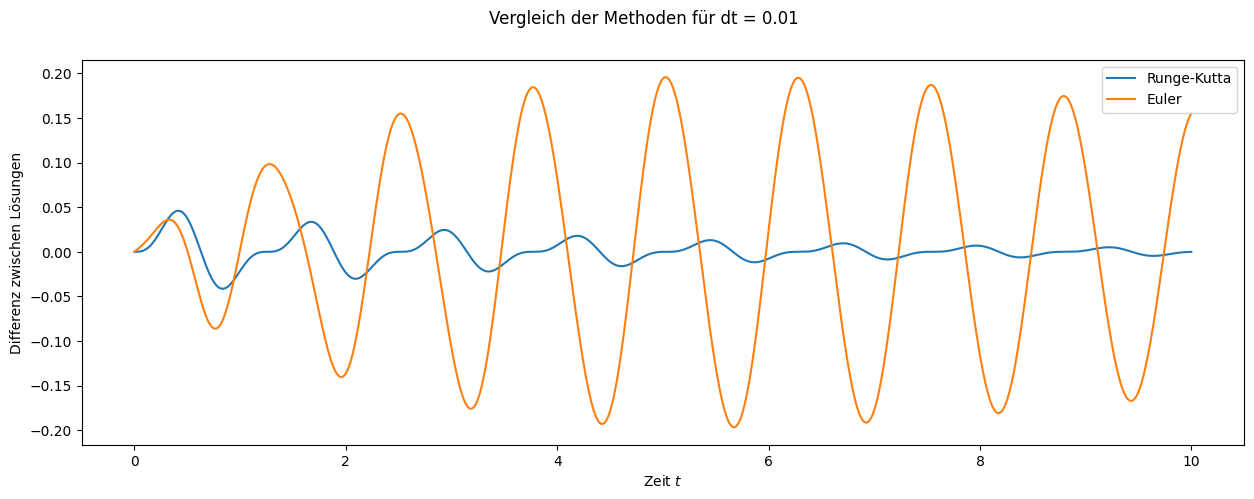

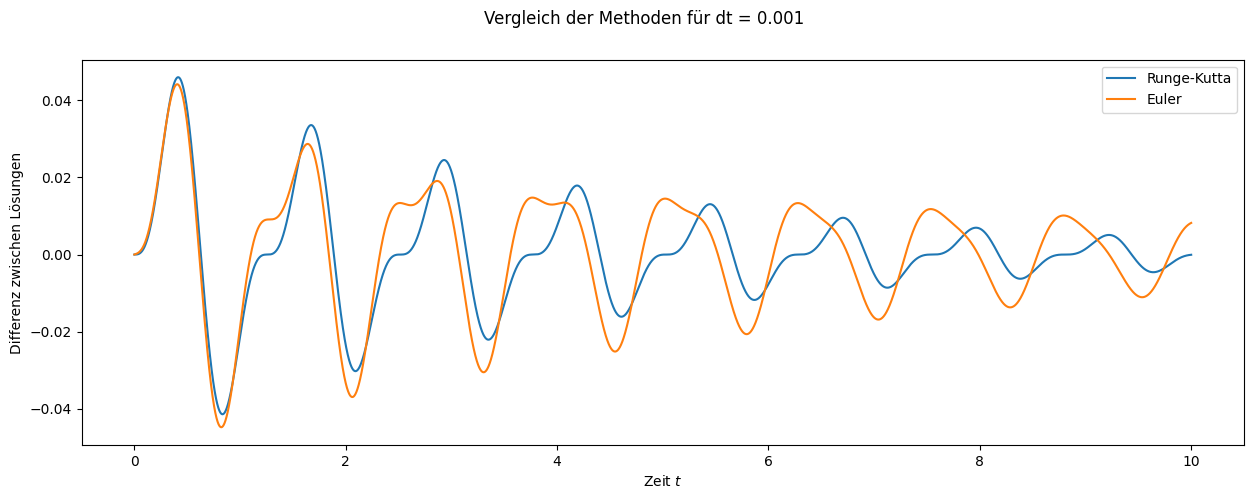

In [114]:
phi0 = np.array([0.25*np.pi,0])
dt = 0.01
params=[5,0.25,0,0]
t0 = 0
tfinal = 10

for dt in [0.01,0.001]:
    start_rk = time.time()
    # Setze hier die Berechnung mithilfe von Runge-Kutta ein
    t,phis_rk = rk4(dgls,t0,tfinal,dt,phi0,params)
    
    end_rk = time.time()
    
    start_euler = time.time()
    # Setze hier die Berechnung mithilfe von Euler ein:
    t,phis_euler = euler(dgls,t0,tfinal,dt,phi0,params)
    end_euler = time.time()
    
    print('Schrittweite: ',dt,'Rechenzeit Runge-Kutta: ', end_rk-start_rk, 's, Rechenzeit Euler: ',end_euler-start_euler, ' s')
    
    # Berechne die analytische Lösung im selber Zeitbereich, wie die numerischen Lösungen
    phi_analytisch = pohl(t,phi0,params)


    # Stelle 
    fig, ax = plt.subplots(figsize=(15,5))

    ax.set_xlabel(r'Zeit $t$')
    ax.set_ylabel(r'Differenz zwischen Lösungen')
    ax.plot(t, phis_rk[:,0]-phi_analytisch, label='Runge-Kutta')
    ax.plot(t, phis_euler[:,0] - phi_analytisch, label='Euler')
    ax.legend()
    fig.suptitle('Vergleich der Methoden für dt = %s'%(dt))


### Vergleichen der Methoden für den gedämpften, harmonischen Oszillator mit Antrieb

Führen Sie einen entsprechenden Vergleich der Methoden für die Simulation mit externem Antrieb durch:

In [ ]:
# Notieren Sie hier ihren Code

## Vergleich mit den experimentellen Daten

Finden Sie passende Parameter zur Modellierung der experimentellen Daten ihrer Messung zur Analyse der Dämpfung ohne externen Antrieb.<br>
Vergleichen Sie die aus ihrer Sicht geeignetere numerische Methode mit den experimentellen Daten für 2 unterschiedliche Dämpfungen. Gehen Sie in vergleichbarer Weise vor, wie beim Vergleich mit der analytischen Lösung.